In [1]:
import numpy as np
from collections import defaultdict
import glob
import json
import pandas as pd
from scipy.integrate import quad, dblquad
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import re
import cv2

class Position2:
  def __init__(self, x=0.0, y=0.0):
    self.x = x
    self.y = y

# Experiment Setup

In [2]:
START_POS = Position2(x=450.0, y=300.0)

OBJECTS_GROUND_TRUTH = {
  "ball": Position2(x=550.0, y=350.0),
  "robot": Position2(x=650.0, y=200.0),
  "X-Intersection": Position2(x=750.0, y=300.0),
  "L-Intersection": Position2(x=800.0, y=450.0),
  "T-Intersection": Position2(x=900.0, y=450.0),
  "goalpost": Position2(x=900.0, y=190.0),
}

# Load Data

In [3]:
def load_ipm_estimations(path, labels=None):
  if labels is None:
    labels = OBJECTS_GROUND_TRUTH.keys()

  estimated = {label: [] for label in labels}

  with open(path, "r") as f:
    data = json.load(f)

    for frame_data in data:
      # Temporary storage
      frame_objects = {label: [] for label in labels}

      for obj in frame_data:
        label = obj["label"]
        if label in frame_objects:
          pos = Position2(x=obj["field_x"], y=obj["field_y"])
          robot = Position2(x=obj["robot_x"], y=obj["robot_y"])
          frame_id = obj["frame"]
          frame_objects[label].append((pos, robot, frame_id))

      for label, objs in frame_objects.items():
        if not objs:
          continue

        if len(objs) > 1:
          gt = OBJECTS_GROUND_TRUTH[label]

          # Pick closest to ground truth
          best = min(
            objs,
            key=lambda x: np.hypot(x[0].x - gt.x, x[0].y - gt.y)
          )
          estimated[label].append(best)
        else:
          for obj in objs:
            estimated[label].append(obj)

  return estimated


dynamic_ipm = []
files = sorted(
    glob.glob("../data/dynamic_ipm_logs_*.json"),
    key=lambda x: int(re.search(r'_(\d+)\.json', x).group(1))
)

for filename in files:
    data = load_ipm_estimations(filename, ["ball", "robot", "X-Intersection"])
    dynamic_ipm.append(data)

# IPM Evaluation

### Error Metrices

In [4]:
def estimated_position_errors(estimated: Position2, actual: Position2, robot: Position2):
  dx = estimated.x - actual.x
  dy = estimated.y - actual.y
  err = np.hypot(dx, dy)

  rel_dx = actual.x - robot.x
  rel_dy = actual.y - robot.y
  dist = np.hypot(rel_dx, rel_dy)

  err_pct = (err / dist) * 100 if dist != 0 else 0.0

  x_pct = (abs(dx) / abs(rel_dx)) * 100 if rel_dx != 0 else 0.0
  y_pct = (abs(dy) / abs(rel_dy)) * 100 if rel_dy != 0 else 0.0

  return dx, dy, err, x_pct, y_pct, err_pct

### Static Evaluation

In [ ]:
static_ipm = load_ipm_estimations("../data/static_ipm_logs.json")

def print_summary_static(title, data, results):
  errors, x_errors, y_errors, x_pct, y_pct, err_pct = results

  print(f"=== {title} ===")

  for label, entries in data.items():
    if len(entries) == 0:
      continue

    xs = [est.x for est, _, _ in entries]
    ys = [est.y for est, _, _ in entries]

    avg_x = np.mean(xs)
    avg_y = np.mean(ys)

    mean_err = np.mean(errors[label])
    mean_err_pct = np.mean(err_pct[label])

    mean_dx = np.mean(x_errors[label])
    mean_dy = np.mean(y_errors[label])

    mean_x_pct = np.mean(x_pct[label])
    mean_y_pct = np.mean(y_pct[label])

    print(f"{label}:")
    print(f"  Avg Position : ({avg_x:.1f}, {avg_y:.1f})")
    print(f"  Mean Error   : {mean_err:.1f} ({mean_err_pct:.1f}%)")
    print(f"  Mean X Error : {mean_dx:.1f} ({mean_x_pct:.1f}%)")
    print(f"  Mean Y Error : {mean_dy:.1f} ({mean_y_pct:.1f}%)")
    print()

def evaluate_static(data):
  errors = defaultdict(list)
  x_errors = defaultdict(list)
  y_errors = defaultdict(list)
  x_pct_errors = defaultdict(list)
  y_pct_errors = defaultdict(list)
  err_pct_errors = defaultdict(list)

  for label, entries in data.items():
    actual = OBJECTS_GROUND_TRUTH[label]

    for est, _, _ in entries:
      dx, dy, err, x_pct, y_pct, err_pct = estimated_position_errors(est, actual, START_POS)

      x_errors[label].append(dx)
      y_errors[label].append(dy)
      errors[label].append(err)
      x_pct_errors[label].append(x_pct)
      y_pct_errors[label].append(y_pct)
      err_pct_errors[label].append(err_pct)

  return errors, x_errors, y_errors, x_pct_errors, y_pct_errors, err_pct_errors

static_results = evaluate_static(static_ipm)
print_summary_static("STATIC IPM", static_ipm, static_results)

=== STATIC IPM ===
ball:
  Avg Position : (549.5, 353.1)
  Mean Error   : 3.1 (2.8%)
  Mean X Error : -0.5 (0.5%)
  Mean Y Error : 3.1 (6.1%)

robot:
  Avg Position : (637.6, 207.9)
  Mean Error   : 14.7 (6.6%)
  Mean X Error : -12.4 (6.2%)
  Mean Y Error : 7.9 (7.9%)

X-Intersection:
  Avg Position : (749.9, 300.4)
  Mean Error   : 2.0 (0.7%)
  Mean X Error : -0.1 (0.6%)
  Mean Y Error : 0.4 (0.0%)

L-Intersection:
  Avg Position : (812.8, 439.2)
  Mean Error   : 16.7 (4.4%)
  Mean X Error : 12.8 (3.6%)
  Mean Y Error : -10.8 (7.2%)

T-Intersection:
  Avg Position : (912.2, 446.8)
  Mean Error   : 12.7 (2.7%)
  Mean X Error : 12.2 (2.7%)
  Mean Y Error : -3.2 (2.1%)

goalpost:
  Avg Position : (944.1, 178.8)
  Mean Error   : 45.5 (9.8%)
  Mean X Error : 44.1 (9.8%)
  Mean Y Error : -11.2 (10.2%)



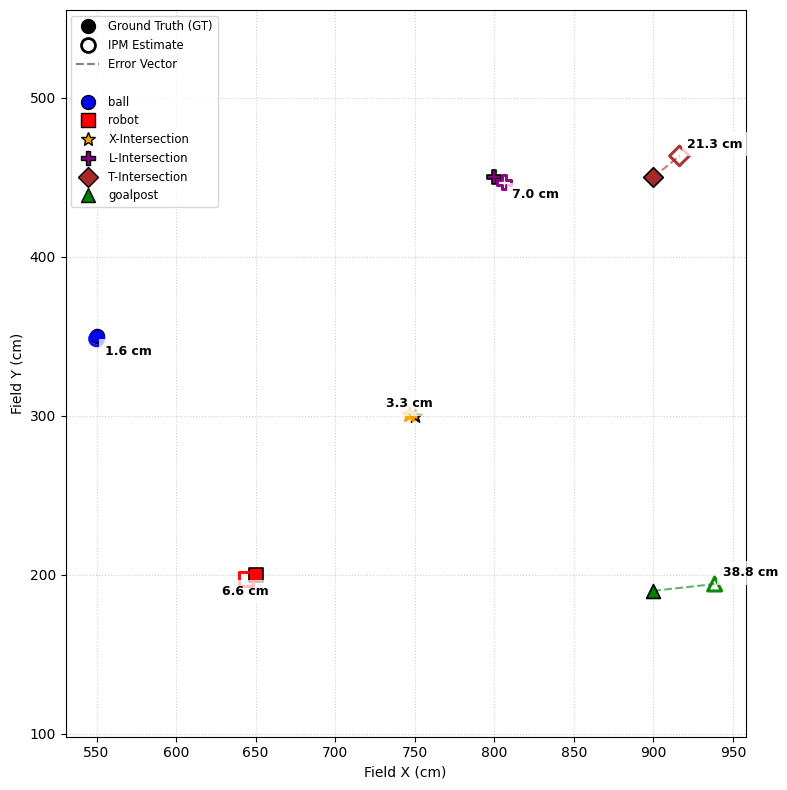

In [6]:
def plot_est_vs_gt_static(static_ipm, static_results, labels=None):

    errors, x_errors, y_errors, _, _, _ = static_results

    if labels is None:
        labels = list(static_ipm.keys())

    plt.figure(figsize=(8, 8))

    # -------------------------------------
    # Colors
    # -------------------------------------

    color_map = {
        "ball": "blue",
        "robot": "red",
        "goalpost": "green",
        "X-Intersection": "orange",
        "L-Intersection": "purple",
        "T-Intersection": "brown"
    }

    # -------------------------------------
    # Marker Shapes
    # -------------------------------------

    marker_map = {
        "ball": "o",
        "robot": "s",
        "goalpost": "^",
        "X-Intersection": "*",
        "L-Intersection": "P",
        "T-Intersection": "D"
    }

    # -------------------------------------
    # Legend
    # -------------------------------------

    legend_elements = [

        # GT explanation
        Line2D(
            [0], [0],
            marker='o',
            color='black',
            linestyle='None',
            label='Ground Truth (GT)',
            markerfacecolor='black',
            markeredgecolor='black',
            markersize=10
        ),

        # Estimate explanation
        Line2D(
            [0], [0],
            marker='o',
            color='black',
            linestyle='None',
            label='IPM Estimate',
            markerfacecolor='none',
            markeredgecolor='black',
            markeredgewidth=2,
            markersize=10
        ),

        # Error vector explanation
        Line2D(
            [0], [0],
            color='gray',
            linestyle='--',
            label='Error Vector'
        ),

        # Spacer
        Line2D([0], [0], color='white', label=' ')
    ]

    # Object legend
    for label in labels:

        marker = marker_map.get(label, "o")
        color = color_map.get(label, "black")

        legend_elements.append(
            Line2D(
                [0], [0],
                marker=marker,
                color=color,
                linestyle='None',
                label=label,
                markerfacecolor=color,
                markeredgecolor='black',
                markersize=10
            )
        )

    # -------------------------------------
    # Plot Objects
    # -------------------------------------

    for label in labels:

        if label not in static_ipm:
            continue

        gt = OBJECTS_GROUND_TRUTH[label]

        color = color_map.get(label, "black")
        marker = marker_map.get(label, "o")

        avg_x = np.mean([est.x for est, _, _ in static_ipm[label]])
        avg_y = np.mean([est.y for est, _, _ in static_ipm[label]])

        mean_dx = np.mean(x_errors[label])
        mean_dy = np.mean(y_errors[label])
        mean_err = np.mean(errors[label])

        offset_x = 5 if mean_dx >= 0 else -15
        offset_y = 5 if mean_dy >= 0 else -10

        # ---------------------------------
        # Ground Truth (Filled)
        # ---------------------------------

        plt.scatter(
            gt.x,
            gt.y,
            marker=marker,
            s=100,
            color=color,
            edgecolors='black',
            linewidths=1.2,
            zorder=3
        )

        # ---------------------------------
        # Estimate (Hollow)
        # ---------------------------------

        plt.scatter(
            avg_x,
            avg_y,
            marker=marker,
            s=100,
            facecolors='none',
            edgecolors=color,
            linewidths=2.2,
            alpha=0.95,
            zorder=3
        )

        # ---------------------------------
        # Error Vector
        # ---------------------------------

        plt.plot(
            [gt.x, avg_x],
            [gt.y, avg_y],
            color=color,
            linestyle='--',
            alpha=0.6,
            linewidth=1.5,
            zorder=2
        )

        # ---------------------------------
        # Error Text
        # ---------------------------------

        plt.text(
            avg_x + offset_x,
            avg_y + offset_y,
            f"{mean_err:.1f} cm",
            fontsize=9,
            fontweight='bold',
            bbox=dict(
                facecolor='white',
                alpha=0.75,
                edgecolor='none'
            ),
            zorder=4
        )

    # -------------------------------------
    # Final Styling
    # -------------------------------------

    plt.xlabel("Field X (cm)")
    plt.ylabel("Field Y (cm)")

    plt.axis('equal')

    plt.grid(
        True,
        linestyle=':',
        alpha=0.6
    )

    plt.legend(
        handles=legend_elements,
        loc='upper left',
        fontsize='small',
        frameon=True
    )

    plt.tight_layout()
    plt.show()

plot_est_vs_gt_static(static_ipm, static_results)

### Dynamic Evaluation

#### Detecting outliers
Outlier exist because of false object detection

In [7]:
def detect_outliers_iqr(values):
  q1 = np.percentile(values, 25)
  q3 = np.percentile(values, 75)
  iqr = q3 - q1

  lower = max(0.0, q1 - 1.5 * iqr)
  upper = q3 + 1.5 * iqr

  mask = [(v < lower) or (v > upper) for v in values]
  return mask, lower, upper

def find_outliers_per_object(runs):
  outliers = {}

  for label in OBJECTS_GROUND_TRUTH.keys():
    all_errors = []
    all_entries = []

    for run in runs:
      if label not in run:
        continue

      actual = OBJECTS_GROUND_TRUTH[label]

      for est, robot, frame in run[label]:
        dx = est.x - actual.x
        dy = est.y - actual.y
        err = np.hypot(dx, dy)

        all_errors.append(err)
        all_entries.append((est, robot, err, frame))

    if len(all_errors) == 0:
      continue

    mask, lower, upper = detect_outliers_iqr(all_errors)

    outliers[label] = []
    for i, is_outlier in enumerate(mask):
      if is_outlier:
        est, robot, err, frame = all_entries[i]
        outliers[label].append((est.x, est.y, err, frame))

    print(f"{label}:")
    print(f"  Bounds: [{lower:.2f}, {upper:.2f}]")
    print(f"  Outliers: {len(outliers[label])}/{len(all_errors)}")

    for o in outliers[label]:
      print(f"    Frame:{o[3]}, ({o[0]:.2f}, {o[1]:.2f}) -> Error {o[2]:.2f}")

    print()

  return outliers

outliers = find_outliers_per_object(dynamic_ipm)

ball:
  Bounds: [0.00, 47.01]
  Outliers: 58/348
    Frame:23, (279.17, 613.60) -> Error 377.94
    Frame:29, (489.71, 273.34) -> Error 97.52
    Frame:30, (518.03, 293.47) -> Error 64.95
    Frame:42, (365.39, 491.57) -> Error 232.64
    Frame:48, (517.23, 279.88) -> Error 77.40
    Frame:80, (544.36, 301.89) -> Error 48.44
    Frame:16, (278.69, 621.31) -> Error 383.69
    Frame:22, (491.68, 282.35) -> Error 89.32
    Frame:23, (514.22, 297.35) -> Error 63.66
    Frame:35, (335.84, 532.66) -> Error 281.47
    Frame:41, (518.86, 289.00) -> Error 68.49
    Frame:73, (544.38, 300.50) -> Error 49.82
    Frame:15, (282.11, 609.15) -> Error 372.73
    Frame:21, (489.50, 271.97) -> Error 98.73
    Frame:34, (341.26, 548.28) -> Error 287.90
    Frame:40, (518.56, 282.20) -> Error 74.74
    Frame:69, (782.24, 310.30) -> Error 235.61
    Frame:16, (271.88, 630.46) -> Error 394.98
    Frame:17, (509.68, 431.78) -> Error 91.18
    Frame:23, (503.50, 279.03) -> Error 84.84
    Frame:35, (371.44, 

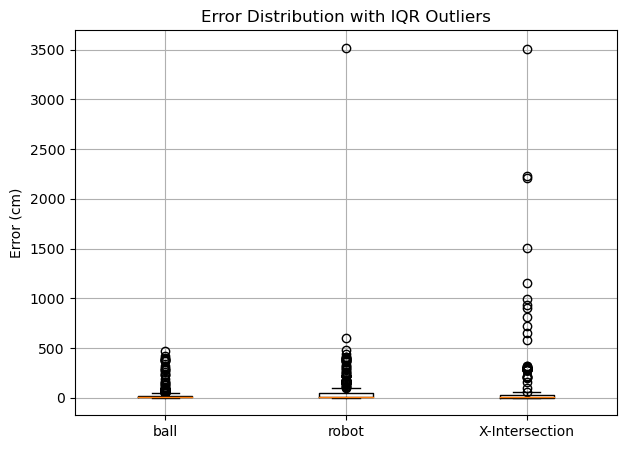

In [27]:
def plot_error_boxplot(dynamic_ipm, labels=None):
    if labels is None:
        labels = OBJECTS_GROUND_TRUTH.keys()

    data = []
    names = []

    for label in labels:
        gt = OBJECTS_GROUND_TRUTH[label]
        errors = []

        for run in dynamic_ipm:
            if label not in run:
                continue

            for est, _, _ in run[label]:
                dx = est.x - gt.x
                dy = est.y - gt.y
                err = np.hypot(dx, dy)
                errors.append(err)

        if len(errors) > 0:
            data.append(errors)
            names.append(label)

    plt.figure(figsize=(7,5))
    plt.boxplot(data, labels=names, showfliers=True)

    plt.ylabel("Error (cm)")
    plt.title("Error Distribution with IQR Outliers")
    plt.grid(True)

    plt.show()
    
plot_error_boxplot(dynamic_ipm, labels=["goalpost", "ball", "robot", "X-Intersection"])

#### Removing outliers

In [28]:
def filter_outliers_per_object(runs, exclude_labels=None):
    if exclude_labels is None:
        exclude_labels = []

    filtered_runs = []

    total_samples = 0
    removed_samples = 0

    for run in runs:
        new_run = {}

        for label, entries in run.items():
            if label not in OBJECTS_GROUND_TRUTH:
                continue

            if label in exclude_labels:
                new_run[label] = entries
                continue

            actual = OBJECTS_GROUND_TRUTH[label]

            errors = []
            for est, robot, frame in entries:
                dx = est.x - actual.x
                dy = est.y - actual.y
                err = np.hypot(dx, dy)
                errors.append(err)

            if len(errors) == 0:
                new_run[label] = entries
                continue

            q1 = np.percentile(errors, 25)
            q3 = np.percentile(errors, 75)
            iqr = q3 - q1

            lower = max(0.0, q1 - 1.5 * iqr)
            upper = q3 + 1.5 * iqr

            filtered_entries = []

            for (est, robot, frame), err in zip(entries, errors):
                total_samples += 1

                if lower <= err <= upper:
                    filtered_entries.append((est, robot, frame))
                else:
                    removed_samples += 1

            new_run[label] = filtered_entries

        filtered_runs.append(new_run)

    removal_percentage = (
        (removed_samples / total_samples) * 100
        if total_samples > 0 else 0.0
    )

    print(f"Total samples   : {total_samples}")
    print(f"Removed samples : {removed_samples}")
    print(f"Removal percent : {removal_percentage:.2f}%")

    return filtered_runs

filtered_dynamic_ipm = filter_outliers_per_object(
  dynamic_ipm,
  # exclude_labels=["ball"]
)

Total samples   : 960
Removed samples : 164
Removal percent : 17.08%


#### Evaluation

In [29]:
def print_summary_dynamic(title, runs, results):
  errors, x_errors, y_errors, x_pct, y_pct, err_pct = results

  all_labels = set()
  for run in runs:
    all_labels.update(run.keys())

  print(f"=== {title} ===")

  for label in all_labels:
    xs, ys = [], []

    for run in runs:
      if label in run:
        xs.extend([est.x for est, _, _ in run[label]])
        ys.extend([est.y for est, _, _ in run[label]])

    if len(xs) == 0:
      continue

    avg_x = np.mean(xs)
    avg_y = np.mean(ys)

    mean_err = np.mean(errors[label])
    mean_err_pct = np.mean(err_pct[label])

    mean_dx = np.mean(x_errors[label])
    mean_dy = np.mean(y_errors[label])

    mean_x_pct = np.mean(x_pct[label])
    mean_y_pct = np.mean(y_pct[label])

    print(f"{label}:")
    print(f"  Avg Position : ({avg_x:.1f}, {avg_y:.1f})")
    print(f"  Mean Error   : {mean_err:.1f} ({mean_err_pct:.1f}%)")
    print(f"  Mean X Error : {mean_dx:.1f} ({mean_x_pct:.1f}%)")
    print(f"  Mean Y Error : {mean_dy:.1f} ({mean_y_pct:.1f}%)")
    print()

def evaluate_dynamic(runs):
  errors = defaultdict(list)
  x_errors = defaultdict(list)
  y_errors = defaultdict(list)
  x_pct_errors = defaultdict(list)
  y_pct_errors = defaultdict(list)
  err_pct_errors = defaultdict(list)

  for run in runs:
    for label, entries in run.items():
      if label not in OBJECTS_GROUND_TRUTH:
        continue

      actual = OBJECTS_GROUND_TRUTH[label]

      for est, robot, _ in entries:
        dx, dy, err, x_pct, y_pct, err_pct = estimated_position_errors(est, actual, robot)

        x_errors[label].append(dx)
        y_errors[label].append(dy)
        errors[label].append(err)
        x_pct_errors[label].append(x_pct)
        y_pct_errors[label].append(y_pct)
        err_pct_errors[label].append(err_pct)

  return errors, x_errors, y_errors, x_pct_errors, y_pct_errors, err_pct_errors

dynamic_results = evaluate_dynamic(filtered_dynamic_ipm)
print_summary_dynamic("DYNAMIC IPM", filtered_dynamic_ipm, dynamic_results)

=== DYNAMIC IPM ===
X-Intersection:
  Avg Position : (743.5, 300.1)
  Mean Error   : 14.1 (5.0%)
  Mean X Error : -6.5 (4.8%)
  Mean Y Error : 0.1 (131.2%)

ball:
  Avg Position : (555.3, 343.7)
  Mean Error   : 11.6 (14.3%)
  Mean X Error : 5.3 (19.8%)
  Mean Y Error : -6.3 (17.1%)

robot:
  Avg Position : (652.7, 202.3)
  Mean Error   : 18.5 (10.1%)
  Mean X Error : 2.7 (7.9%)
  Mean Y Error : 2.3 (11.6%)



In [30]:
def summarize_per_run_per_object(runs):
    summary = []

    for i, run in enumerate(runs):
        for label, entries in run.items():
            if label not in OBJECTS_GROUND_TRUTH:
                continue
            actual = OBJECTS_GROUND_TRUTH[label]
            est_x, est_y = [], []
            ex_list, ey_list, e_list = [], [], []

            for est, robot, _ in entries:
                dx, dy, err, *_ = estimated_position_errors(est, actual, robot)
                est_x.append(est.x)
                est_y.append(est.y)
                ex_list.append(dx)
                ey_list.append(dy)
                e_list.append(err)

            if len(e_list) == 0:
                continue

            summary.append({
                "trial": i + 1,
                "label": label,
                "est_x": np.mean(est_x),
                "est_y": np.mean(est_y),
                "mean_ex": np.mean(ex_list),
                "mean_ey": np.mean(ey_list),
                "mean_e": np.mean(e_list),
            })

    return summary
  
def print_summary_per_run_per_object(title, summary):
    print(f"=== {title} ===")

    print(f"{'Trial':<6} {'Objek':<16} {'Est X':>8} {'Est Y':>8} "
          f"{'Mean Ex':>10} {'Mean Ey':>10} {'Mean E':>10}")

    for row in summary:
        print(f"{row['trial']:<6} {row['label']:<16} "
              f"{row['est_x']:>8.1f} {row['est_y']:>8.1f} "
              f"{row['mean_ex']:>10.1f} {row['mean_ey']:>10.1f} {row['mean_e']:>10.1f}")
  
per_run_summary = summarize_per_run_per_object(filtered_dynamic_ipm)
print_summary_per_run_per_object("DYNAMIC IPM PER RUN", per_run_summary)

=== DYNAMIC IPM PER RUN ===
Trial  Objek               Est X    Est Y    Mean Ex    Mean Ey     Mean E
1      ball                554.6    341.8        4.6       -8.2       10.5
1      robot               651.7    201.6        1.7        1.6       14.8
1      X-Intersection      748.7    299.5       -1.3       -0.5        3.1
2      ball                555.7    348.6        5.7       -1.4        9.6
2      robot               645.3    208.1       -4.7        8.1       25.1
2      X-Intersection      749.7    300.8       -0.3        0.8        6.5
3      ball                555.5    345.1        5.5       -4.9        8.7
3      robot               654.2    201.6        4.2        1.6       19.9
3      X-Intersection      742.8    300.8       -7.2        0.8        9.3
4      ball                551.7    338.9        1.7      -11.1       20.4
4      robot               656.2    205.9        6.2        5.9       23.7
4      X-Intersection      748.6    301.4       -1.4        1.4        9

In [31]:
def print_dynamic_runs(dynamic_logs, run_indices=None, labels=None):
  if run_indices is None:
    run_indices = list(range(len(dynamic_logs)))
  
  if labels is None:
    labels = OBJECTS_GROUND_TRUTH.keys()

  print("=== DYNAMIC IPM RAW (FILTERED) ===")

  for i in run_indices:
    if i >= len(dynamic_logs):
      continue

    run = dynamic_logs[i]
    print(f"\n--- Run {i} ---")

    for label in labels:
      if label not in run or not run[label]:
        continue

      print(f"{label}:")

      for est, robot, frame in run[label]:
        print(
          f"  Frame {frame} | "
          f"Est: ({est.x:.2f}, {est.y:.2f}) | "
          f"Robot: ({robot.x:.2f}, {robot.y:.2f})"
        )
        
print_dynamic_runs(filtered_dynamic_ipm, labels=["ball"])

=== DYNAMIC IPM RAW (FILTERED) ===

--- Run 0 ---
ball:
  Frame 0 | Est: (552.56, 345.67) | Robot: (450.00, 300.00)
  Frame 1 | Est: (552.54, 345.27) | Robot: (450.00, 300.00)
  Frame 2 | Est: (552.54, 345.27) | Robot: (450.00, 300.00)
  Frame 3 | Est: (552.56, 345.67) | Robot: (450.00, 300.00)
  Frame 4 | Est: (552.56, 345.67) | Robot: (450.00, 300.00)
  Frame 5 | Est: (552.54, 345.27) | Robot: (450.00, 300.00)
  Frame 6 | Est: (552.54, 345.27) | Robot: (450.00, 300.00)
  Frame 7 | Est: (552.56, 345.67) | Robot: (450.00, 300.00)
  Frame 8 | Est: (552.56, 345.67) | Robot: (450.00, 300.00)
  Frame 9 | Est: (552.56, 345.67) | Robot: (450.00, 300.00)
  Frame 10 | Est: (552.54, 345.27) | Robot: (450.00, 300.00)
  Frame 11 | Est: (552.54, 345.27) | Robot: (450.00, 300.00)
  Frame 12 | Est: (552.54, 345.27) | Robot: (450.00, 300.00)
  Frame 13 | Est: (552.56, 345.67) | Robot: (450.00, 300.00)
  Frame 14 | Est: (552.11, 345.18) | Robot: (450.00, 300.00)
  Frame 15 | Est: (551.84, 345.41) | Ro

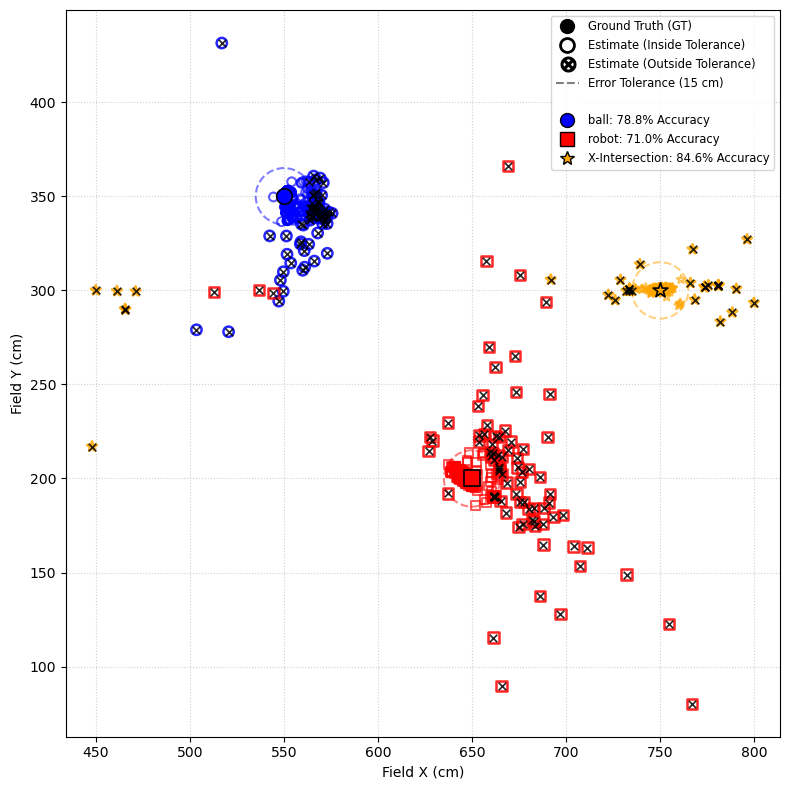

In [44]:
def plot_est_vs_gt_dynamic(dynamic_ipm, labels=None, radius=15):

    if labels is None:
        labels = ["ball", "robot", "X-Intersection"]

    plt.figure(figsize=(8, 8))

    # -------------------------------------
    # Colors
    # -------------------------------------

    color_map = {
        "ball": "blue",
        "robot": "red",
        "goalpost": "green",
        "X-Intersection": "orange",
        "L-Intersection": "purple",
        "T-Intersection": "brown"
    }

    # -------------------------------------
    # Marker Shapes
    # -------------------------------------

    marker_map = {
        "ball": "o",
        "robot": "s",
        "goalpost": "^",
        "X-Intersection": "*",
        "L-Intersection": "P",
        "T-Intersection": "D"
    }

    # -------------------------------------
    # Legend
    # -------------------------------------

    legend_elements = [

        # GT explanation
        Line2D(
            [0], [0],
            marker='o',
            color='black',
            linestyle='None',
            label='Ground Truth (GT)',
            markerfacecolor='black',
            markeredgecolor='black',
            markersize=10
        ),

        # Estimate inside tolerance
        Line2D(
            [0], [0],
            marker='o',
            color='black',
            linestyle='None',
            label='Estimate (Inside Tolerance)',
            markerfacecolor='none',
            markeredgecolor='black',
            markeredgewidth=2,
            markersize=10
        ),

        # Estimate outside tolerance
        Line2D(
            [0], [0],
            marker=r'$\otimes$',
            color='black',
            linestyle='None',
            label='Estimate (Outside Tolerance)',
            markersize=12
        ),

        # Tolerance circle
        Line2D(
            [0], [0],
            color='gray',
            linestyle='--',
            label=f'Error Tolerance ({radius} cm)'
        ),

        # Spacer
        Line2D([0], [0], color='white', label=' ')
    ]

    # -------------------------------------
    # Object Legend
    # -------------------------------------

    for label in labels:

        marker = marker_map.get(label, "o")
        color = color_map.get(label, "black")

        gt = OBJECTS_GROUND_TRUTH[label]

        total = 0
        inside = 0

        for run in dynamic_ipm:

            if label in run:

                for est, _, _ in run[label]:

                    total += 1

                    dx = est.x - gt.x
                    dy = est.y - gt.y

                    err = np.hypot(dx, dy)

                    if err <= radius:
                        inside += 1

        pct_inside = (inside / total) * 100 if total > 0 else 0

        legend_elements.append(
            Line2D(
                [0], [0],
                marker=marker,
                color=color,
                linestyle='None',
                label=f"{label}: {pct_inside:.1f}% Accuracy",
                markerfacecolor=color,
                markeredgecolor='black',
                markersize=10
            )
        )

    # -------------------------------------
    # Plot Objects
    # -------------------------------------

    for label in labels:

        gt = OBJECTS_GROUND_TRUTH[label]

        color = color_map.get(label, "black")
        marker = marker_map.get(label, "o")

        all_points = []

        for run in dynamic_ipm:

            if label in run:
                all_points.extend(run[label])

        if not all_points:
            continue

        inside_xs, inside_ys = [], []
        outside_xs, outside_ys = [], []

        # ---------------------------------
        # Split Inside / Outside
        # ---------------------------------

        for est, _, _ in all_points:

            dx = est.x - gt.x
            dy = est.y - gt.y

            err = np.hypot(dx, dy)

            if err <= radius:

                inside_xs.append(est.x)
                inside_ys.append(est.y)

            else:

                outside_xs.append(est.x)
                outside_ys.append(est.y)

        # ---------------------------------
        # Ground Truth (Filled)
        # ---------------------------------

        plt.scatter(
            gt.x,
            gt.y,
            marker=marker,
            s=125,
            color=color,
            edgecolors='black',
            linewidths=1.2,
            zorder=5
        )

        # ---------------------------------
        # Tolerance Circle
        # ---------------------------------

        circle = plt.Circle(
            (gt.x, gt.y),
            radius,
            color=color,
            fill=False,
            linestyle='--',
            linewidth=1.5,
            alpha=0.5,
            zorder=2
        )

        plt.gca().add_patch(circle)

        # ---------------------------------
        # Inside Tolerance (Hollow)
        # ---------------------------------

        plt.scatter(
            inside_xs,
            inside_ys,
            marker=marker,
            s=40,
            facecolors='none',
            edgecolors=color,
            linewidths=1.5,
            alpha=0.65,
            zorder=3
        )

        # ---------------------------------
        # Outside Tolerance
        # ---------------------------------

        # Hollow object marker
        plt.scatter(
            outside_xs,
            outside_ys,
            marker=marker,
            s=55,
            facecolors='none',
            edgecolors=color,
            linewidths=1.8,
            alpha=0.85,
            zorder=4
        )

        # Black X overlay
        plt.scatter(
            outside_xs,
            outside_ys,
            marker='x',
            s=30,
            color='black',
            linewidths=1.2,
            alpha=0.85,
            zorder=5
        )

    # -------------------------------------
    # Final Styling
    # -------------------------------------

    plt.xlabel("Field X (cm)")
    plt.ylabel("Field Y (cm)")

    plt.axis('equal')

    plt.grid(
        True,
        linestyle=':',
        alpha=0.6
    )

    plt.legend(
        handles=legend_elements,
        loc='upper right',
        fontsize='small',
        frameon=True
    )

    plt.tight_layout()
    plt.show()


plot_est_vs_gt_dynamic(
    filtered_dynamic_ipm,
    labels=["ball", "robot", "X-Intersection"]
)

In [29]:
def calculate_dynamic_stats(dynamic_data):
    # dynamic_data is your list of 10 dicts (one per trial)
    all_results = []

    for label in ["ball", "robot", "X-Intersection"]:
        actual = OBJECTS_GROUND_TRUTH[label]
        dist_to_obj = np.hypot(actual.x - 450, actual.y - 300)
        
        # Collect all Euclidean errors for this object across ALL trials
        e_list = []
        ex_list = []
        ey_list = []

        for run in dynamic_data:
            if label in run:
                for est, _, _ in run[label]:
                    dx = est.x - actual.x
                    dy = est.y - actual.y
                    err = np.hypot(dx, dy)
                    
                    e_list.append(err)
                    ex_list.append(dx)
                    ey_list.append(dy)

        if not e_list:
            continue

        # Calculate Stats
        mae = np.mean(e_list)
        rmse = np.sqrt(np.mean(np.square(e_list)))
        std_dev = np.std(e_list)
        # Using mean of absolute errors for axis-wise to show bias
        mean_ex = np.mean(ex_list)
        mean_ey = np.mean(ey_list)
        
        # Normalized Error E% (using MAE)
        e_pct = (mae / dist_to_obj) * 100

        all_results.append({
            "Obj": label,
            "MAE (E)": mae,
            "RMSE": rmse,
            "Std Dev": std_dev,
            "E%": e_pct,
            "Ex": mean_ex,
            "Ey": mean_ey
        })

    return pd.DataFrame(all_results)

# Run it
dynamic_stats_df = calculate_dynamic_stats(filtered_dynamic_ipm)
print(dynamic_stats_df.round(2))

              Obj  MAE (E)   RMSE  Std Dev     E%    Ex    Ey
0            ball    11.56  16.12    11.23  10.34  5.29 -6.26
1           robot    18.47  33.44    27.88   8.26  2.72  2.33
2  X-Intersection    14.14  50.17    48.13   4.71 -6.52  0.08


#### Horizon Line Visualization

In [15]:
u_start = 0
v_start = 82.9064

u_end = 320
v_end = 85.3115

horizon_color = (0, 255, 255) 
line_thickness = 2

text_color = (255, 255, 0)

image_path = '../docs/static_ipm_camera_view.jpeg'
img = cv2.imread(image_path)

if img is None:
    print(f"Error: Could not load image at {image_path}. Make sure the file exists.")
    exit()

start_point = (int(u_start), int(v_start))
end_point = (int(u_end), int(v_end))

cv2.line(img, start_point, end_point, horizon_color, line_thickness)

output_path = '../docs/horizon_visualization.jpeg'
cv2.imwrite(output_path, img)
print(f"Visualization saved to {output_path}")

Visualization saved to ../docs/horizon_visualization.jpeg


#### Numerical Simulation

In [23]:
import numpy as np

fx = 244.15560035753052
fy = 244.6064697061835
cx = 151.04566893941345
cy = 127.51539461608331

R = np.array([
    [0.00193602, -0.174973, 0.984571],
    [-0.999971, -0.00761104, 0.000613707],
    [0.00738623, -0.984544, -0.174982]
])

t = np.array([0.132858, -0.123182, 0.572371])

W, H = 320, 240

A = R[2, 0] / fx
B = R[2, 1] / fy
C = R[2, 2] - (cx * R[2, 0] / fx) - (cy * R[2, 1] / fy)
line_norm = np.sqrt(A**2 + B**2)


def map_pixel(u, v, sigma=25.0, min_confidence=0.4):
    x = (u - cx) / fx
    y = (v - cy) / fy

    denom = R[2,0]*x + R[2,1]*y + R[2,2]
    
    if denom >= 0:
        confidence = 0.0
    else:
        # 2. Calculate distance and a clean 0.0 to 1.0 confidence score
        pixel_dist_to_horizon = abs(denom) / line_norm
        confidence = 1.0 - np.exp(-pixel_dist_to_horizon / sigma)

    # 3. Projection Math (Only execute full math if it's a valid, confident point)
    if confidence >= min_confidence:
        status = "Ya"
    else:
        status = "Tidak"

    Zc = -t[2] / denom
    Xc = x * Zc
    Yc = y * Zc
    Pc = np.array([Xc, Yc, Zc])

    Pb = R @ Pc + t
    Xb, Yb, Zb = Pb[0], Pb[1], Pb[2]
    dist = np.hypot(Xb, Yb)

    return (u, v, x, y, Xc, Yc, Zc, Xb, Yb, Zb, dist, status, confidence)


step_u = 10
step_v = 10

u_vals = list(range(0, W, step_u))
v_vals = list(range(0, H, step_v))

grid_w = len(u_vals)
grid_h = len(v_vals)

Y_map = np.zeros((grid_h, grid_w))

results = []

for i_v, v in enumerate(v_vals):
    for i_u, u in enumerate(u_vals):
        res = map_pixel(u, v)
        results.append(res)

results = np.array(results, dtype=object)

# Export data to excel
table_data = []
idx = 0
for i_v, v in enumerate(v_vals):
    for i_u, u in enumerate(u_vals):
        u, v, x, y, Xc, Yc, Zc, Xb, Yb, Zb, dist, status, confidence = results[idx]
        idx += 1

        if status == "Ya":
            Y_map[i_v, i_u] = dist
        else:
            Y_map[i_v, i_u] = np.nan
        
        table_data.append({
            "(u, v)": f"({u:.0f}, {v:.0f})",
            "(x, y)": f"({x:.2f}, {y:.2f})",
            "Pc (cm)": f"({Xc*100:.0f}, {Yc*100:.0f}, {Zc*100:.0f})",
            "Pb (cm)": f"({Xb*100:.0f}, {Yb*100:.0f}, {Zb*100:.0f})",
            "D (cm)": f"{dist*100:.0f}",
            "Valid": status,
            "Confidence": confidence
        })

df = pd.DataFrame(table_data)
# df.to_excel("../data/simulasi_numerik.xlsx", index=False)
print("Data exported to ../data/simulasi_numerik.xlsx")

Data exported to ../data/simulasi_numerik.xlsx


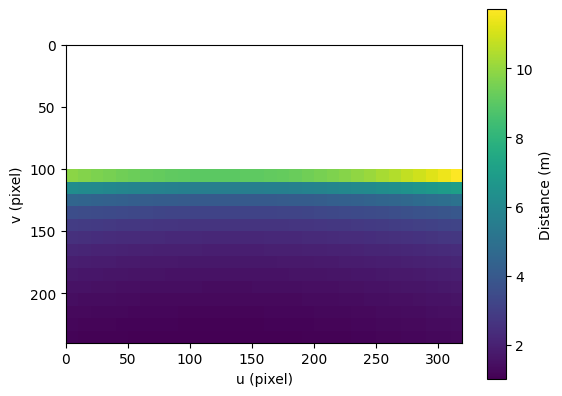

In [24]:
plt.figure()
plt.imshow(Y_map, extent=[0, W, H, 0])
plt.colorbar(label="Distance (m)")
plt.xlabel("u (pixel)")
plt.ylabel("v (pixel)")
plt.show()

#### Odometry Evaluation (Martinelli)

In [18]:
df = pd.read_csv('../data/dynamic_ipm_positions.csv')
n = len(df)

df['delta_x'] = df['estimated_pos_x'] - df['actual_pos_x']
df['delta_y'] = df['estimated_pos_y'] - df['actual_pos_y']
df['delta_orientation'] = df['estimated_orientation'] - df['actual_orientation']

df.head(10)

,estimated_pos_x,estimated_pos_y,actual_pos_x,actual_pos_y,estimated_orientation,actual_orientation,delta_x,delta_y,delta_orientation
0,544.4,301.9,542.5,302.1,-11.5625,-11.5,1.9,-0.2,-0.0625
1,544.4,300.5,543.1,300.7,-0.4375,-0.4,1.3,-0.2,-0.0375
2,544.4,301.0,543.2,301.5,-2.8750,-2.8,1.2,-0.5,-0.0750
3,544.4,299.4,543.1,300.8,0.3125,0.3,1.3,-1.4,0.0125
4,544.4,299.3,543.2,300.5,-0.6875,-0.7,1.2,-1.2,0.0125
5,544.4,298.5,542.8,301.3,-0.8750,-0.8,1.6,-2.8,-0.0750
6,544.4,299.3,542.5,300.2,1.5250,1.5,1.9,-0.9,0.0250
7,544.4,298.4,542.0,299.2,2.9375,2.9,2.4,-0.8,0.0375
8,544.4,302.0,542.6,301.2,-7.7500,-7.6,1.8,0.8,-0.1500
9,544.4,300.5,542.8,302.2,-1.9375,-1.8,1.6,-1.7,-0.1375


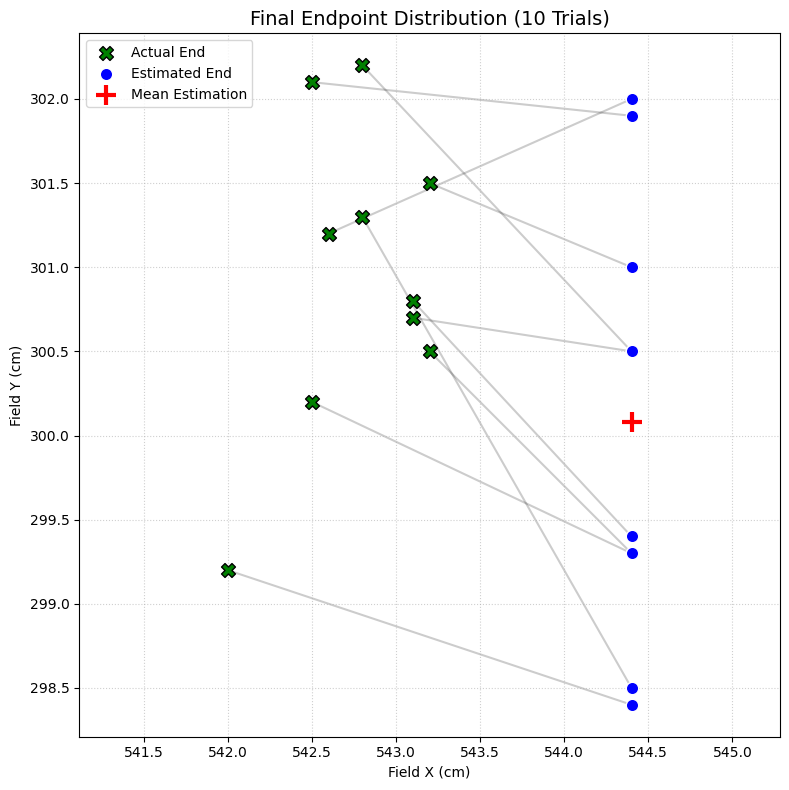

In [19]:
import matplotlib.pyplot as plt
import numpy as np

def plot_final_pose_clusters(df):
    plt.figure(figsize=(8, 8))
    
    # 1. Plot Actual vs Estimated for each trial
    for i in range(len(df)):
        # Line connecting actual to estimated for that trial
        plt.plot([df.loc[i, 'actual_pos_x'], df.loc[i, 'estimated_pos_x']], 
                 [df.loc[i, 'actual_pos_y'], df.loc[i, 'estimated_pos_y']], 
                 'k-', alpha=0.2, zorder=1)
        
        # Plot points
        plt.scatter(df.loc[i, 'actual_pos_x'], df.loc[i, 'actual_pos_y'], 
                    marker='X', color='green', s=100, edgecolors='black', label='Actual End' if i == 0 else "", zorder=3)
        plt.scatter(df.loc[i, 'estimated_pos_x'], df.loc[i, 'estimated_pos_y'], 
                    marker='o', color='blue', s=80, edgecolors='white', label='Estimated End' if i == 0 else "", zorder=2)

    # Calculate and plot the mean of the estimations
    mean_est_x = df['estimated_pos_x'].mean()
    mean_est_y = df['estimated_pos_y'].mean()
    plt.scatter(mean_est_x, mean_est_y, color='red', marker='+', s=200, linewidths=3, label='Mean Estimation', zorder=4)

    plt.title("Final Endpoint Distribution (10 Trials)", fontsize=14)
    plt.xlabel("Field X (cm)")
    plt.ylabel("Field Y (cm)")
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    
    # Set limits based on data to "zoom in" on the target area
    plt.axis('equal')
    plt.tight_layout()
    plt.show()

plot_final_pose_clusters(df)

In [ ]:
rho_target_cm = 100 # Target was 1 meter

# Distance the robot *thinks* it traveled (Encoder Distance)
rho_bar = np.mean(
  np.sqrt((df['estimated_pos_x'] - START_POS.x)**2 +
          (df['estimated_pos_y'] - START_POS.y)**2)
)

# Conversions for Calculation (Must be in Radians)
df['actual_rad'] = np.radians(df['actual_orientation'])
df['est_rad'] = np.radians(df['estimated_orientation'])
phi_est = df['est_rad'].mean()

# Compute Observables (Eq. 15-19)
phi_0 = 0.0
phi_1 = df['actual_rad'].mean()
phi_2 = df['actual_rad'].var(ddof=1)
dx = df['actual_pos_x'] - START_POS.x
dy = df['actual_pos_y'] - START_POS.y
phi_3 = np.mean(dx * np.cos(phi_est) + dy * np.sin(phi_est))
phi_5 = ((dx)**2 + (dy)**2).mean()

# Solve for Parameters (in Radians/CM first)
Er_rad = (phi_1 - phi_est) / rho_bar
K_theta_rad2 = phi_2 / rho_bar

# Solve for Et (Eq. 29)
def integrand_x(s, Er, K_theta):
    return np.cos(phi_0 + Er * s) * np.exp(-K_theta * s / 2.0)

int_val_x, _ = quad(integrand_x, 0, rho_bar, args=(Er_rad, K_theta_rad2))
one_plus_Et = phi_3 / int_val_x
Et = one_plus_Et - 1

# Solve for K_rho (Eq. 32)
def integrand_p5(s_p, s, Er, K_theta):
    return np.exp(-K_theta * s_p / 2.0) * np.cos(phi_0 + Er * s_p)

res_p5_int, _ = dblquad(
  integrand_p5,
  0, rho_bar,
  lambda s: 0,
  lambda s: rho_bar - s,
  args=(Er_rad, K_theta_rad2)
)

K_rho = (phi_5 - 2 * (one_plus_Et**2) * res_p5_int) / rho_bar

# Convert units
Er_deg = np.degrees(Er_rad)
K_theta_deg2 = (np.degrees(1)**2 * K_theta_rad2)
Et_percent = Et * 100

print(f"Er: {Er_deg:.4f} deg/cm")
print(f"K_theta: {K_theta_deg2:.4f} deg^2/cm")
print(f"Et: {Et_percent:.4f}%")
print(f"K_rho: {K_rho:.6f} cm")

Er: 0.0005 deg/cm
K_theta: 0.1994 deg^2/cm
Et: -1.6902%
K_rho: 0.042551 cm


# Comparison with Regression Method

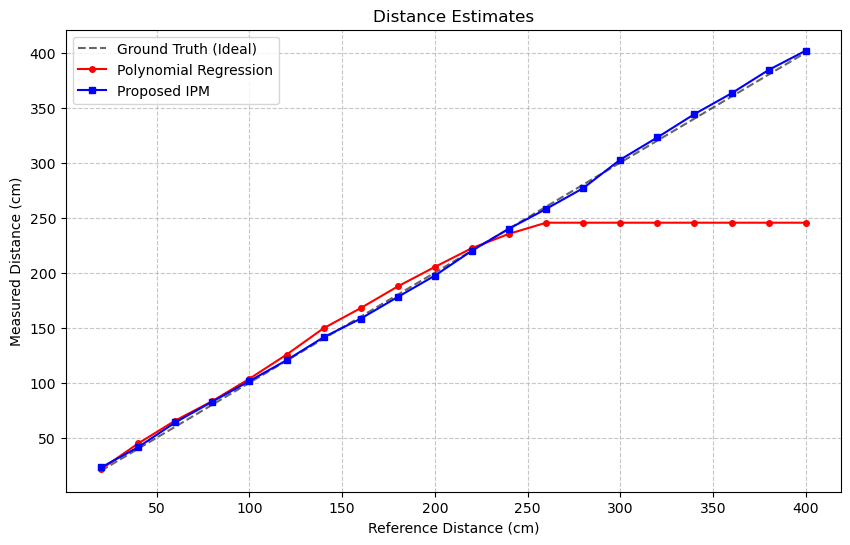

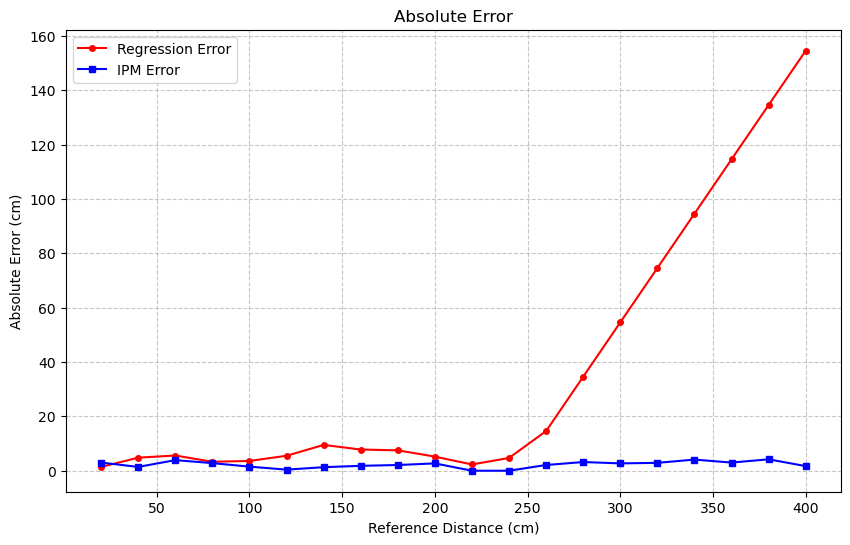

In [21]:
df = pd.read_csv("../data/regression_vs_ipm.csv")

# Calculate absolute error
df['regression_error'] = (df['regression'] - df['dist']).abs()
df['ipm_error'] = (df['ipm'] - df['dist']).abs()

plt.figure(figsize=(10, 6))
plt.plot(df['dist'], df['dist'], 'k--', label='Ground Truth (Ideal)', alpha=0.6)
plt.plot(df['dist'], df['regression'], 'r-o', label='Polynomial Regression', markersize=4)
plt.plot(df['dist'], df['ipm'], 'b-s', label='Proposed IPM', markersize=4)
plt.ylabel('Measured Distance (cm)')
plt.xlabel('Reference Distance (cm)')
plt.title('Distance Estimates')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.figure(figsize=(10, 6))
plt.plot(df['dist'], df['regression_error'], 'r-o', label='Regression Error', markersize=4)
plt.plot(df['dist'], df['ipm_error'], 'b-s', label='IPM Error', markersize=4)
plt.xlabel('Reference Distance (cm)')
plt.ylabel('Absolute Error (cm)')
plt.title('Absolute Error')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

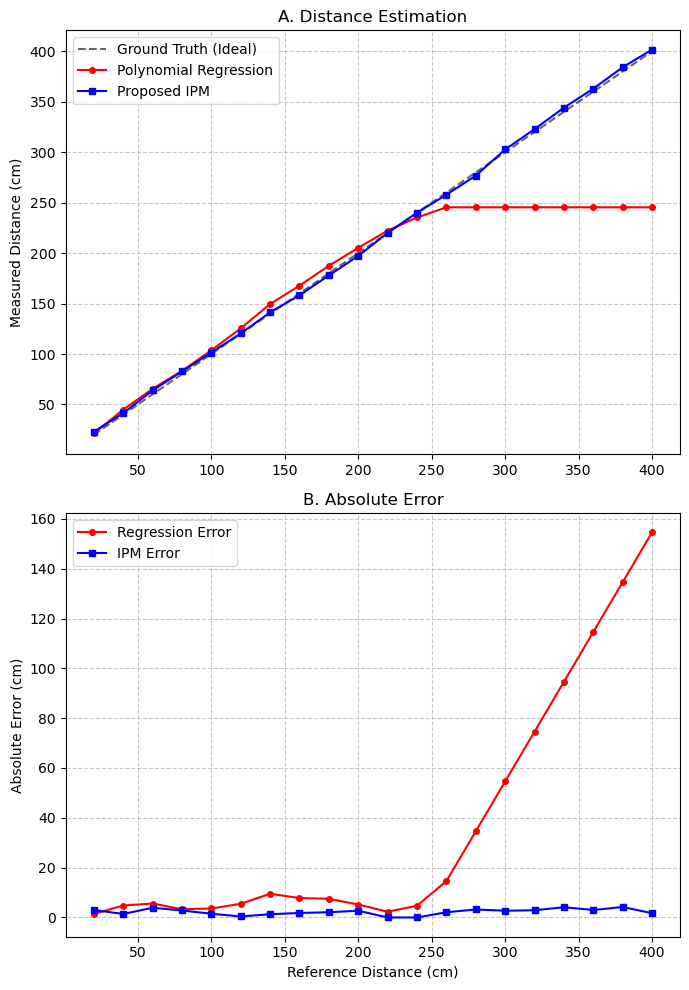

In [25]:

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 10))

ax1.plot(df['dist'], df['dist'], 'k--', label='Ground Truth (Ideal)', alpha=0.6)
ax1.plot(df['dist'], df['regression'], 'r-o', label='Polynomial Regression', markersize=4)
ax1.plot(df['dist'], df['ipm'], 'b-s', label='Proposed IPM', markersize=4)
ax1.set_ylabel('Measured Distance (cm)')
# We can remove the xlabel from the top plot if they share the same axis to save space
ax1.set_title('A. Distance Estimation')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# --- Plot 2: Absolute Error (Bottom) ---
ax2.plot(df['dist'], df['regression_error'], 'r-o', label='Regression Error', markersize=4)
ax2.plot(df['dist'], df['ipm_error'], 'b-s', label='IPM Error', markersize=4)
ax2.set_xlabel('Reference Distance (cm)')
ax2.set_ylabel('Absolute Error (cm)')
ax2.set_title('B. Absolute Error')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

# Adjust layout to prevent title/label overlap
plt.tight_layout()
plt.show()

In [26]:
def calculate_comparison_stats(df):
    methods = ['regression', 'ipm']
    results = {}
    
    for method in methods:
        # Get the absolute error for this method
        error = (df[method] - df['dist']).abs()
        
        results[method] = {
            "MAE (cm)": error.mean(),
            "RMSE (cm)": np.sqrt(np.mean(error**2)),
            "Max Error (cm)": error.max(),
            "Std Dev (cm)": error.std()
        }
    
    return pd.DataFrame(results).T

# Run the calculation
stats_df = calculate_comparison_stats(df)
print("=== Comparative Statistical Analysis ===")
print(stats_df.round(2))

=== Comparative Statistical Analysis ===
            MAE (cm)  RMSE (cm)  Max Error (cm)  Std Dev (cm)
regression     36.90      61.00           154.6         49.84
ipm             2.24       2.55             4.2          1.24
